In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve


In [2]:
processed_dir = Path("../data/processed")
figures_dir = Path("../figures")
results_dir = Path("../results")

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)


In [3]:
heart_final = pd.read_csv(processed_dir / "heart_final.csv")
train_data = heart_final[heart_final["split"] == "train"].copy()
test_data = heart_final[heart_final["split"] == "test"].copy()

X_train = train_data.drop(columns=["target", "split"])
y_train = train_data["target"]
X_test = test_data.drop(columns=["target", "split"])
y_test = test_data["target"]

X_train.shape, X_test.shape


((736, 27), (184, 27))

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logistic_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
cv_scores = cross_val_score(logistic_model, X_train, y_train, cv=cv, scoring="accuracy")
cv_scores.mean(), cv_scores.std()


(np.float64(0.8274131274131274), np.float64(0.034717677303943956))

In [5]:
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]


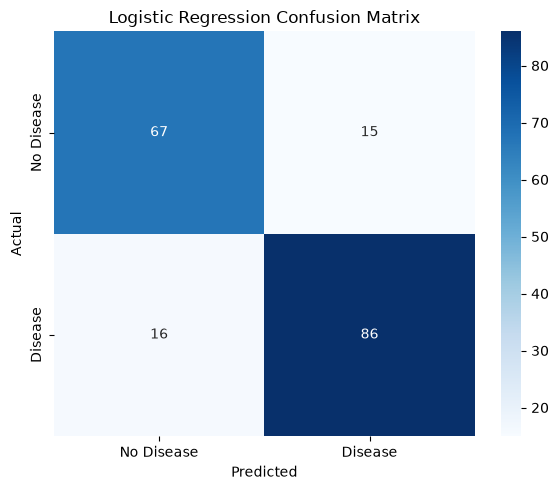

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_logistic.png", dpi=300)
plt.show()


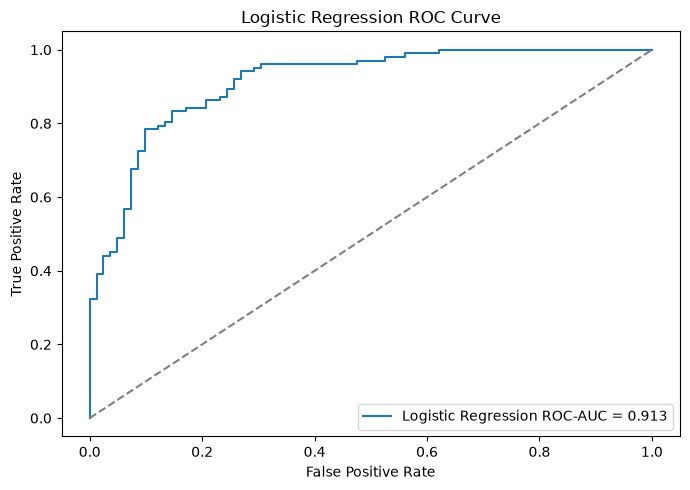

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "roc_curve_logistic.png", dpi=300)
plt.show()


In [8]:
coefficient_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": logistic_model.coef_[0],
})
coefficient_importance["absolute_coefficient"] = coefficient_importance["coefficient"].abs()
coefficient_importance = coefficient_importance.sort_values("absolute_coefficient", ascending=False)
coefficient_importance.head(15)


,feature,coefficient,absolute_coefficient
9,dataset_switzerland,1.954407,1.954407
7,dataset_cleveland,-1.062179,1.062179
11,cp_asymptomatic,1.049586,1.049586
8,dataset_hungary,-0.935338,0.935338
25,exang,0.902522,0.902522
12,cp_atypical angina,-0.768988,0.768988
26,ca,0.695668,0.695668
4,oldpeak,0.682252,0.682252
22,thal_normal,-0.601870,0.601870
5,sex_female,-0.593100,0.593100


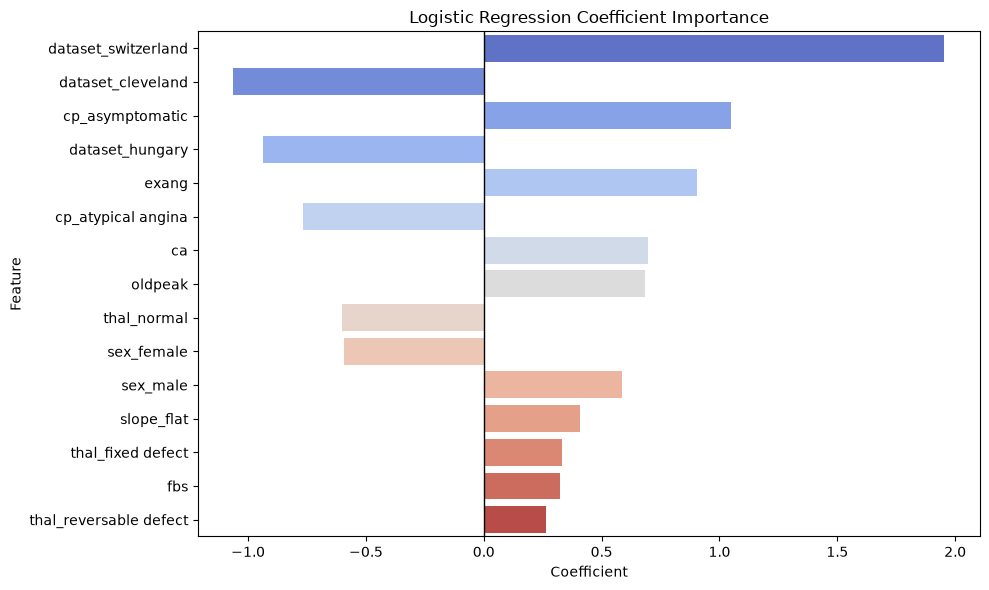

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=coefficient_importance.head(15), x="coefficient", y="feature", hue="feature", legend=False, palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficient Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "logistic_coefficient_importance.png", dpi=300)
plt.show()


In [10]:
logistic_metrics = pd.DataFrame([{
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": auc_score,
    "cv_mean": cv_scores.mean(),
    "cv_std": cv_scores.std()
}])

roc_data = pd.DataFrame({"model": "Logistic Regression", "fpr": fpr, "tpr": tpr})
logistic_metrics


,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,Logistic Regression,0.831522,0.851485,0.843137,0.847291,0.913439,0.827413,0.034718


In [11]:
logistic_metrics.to_csv(results_dir / "logistic_metrics.csv", index=False)
roc_data.to_csv(results_dir / "logistic_roc_curve.csv", index=False)
coefficient_importance.to_csv(results_dir / "logistic_coefficients.csv", index=False)
